# Overview
In this project, I'm implementing a simple linear neural network that reads in text and uses pretrained embeddings to predict the **happiness intensity** of the text.
You'll fit the network weights using the analytic expression we discussed in class.

For this assignment we will use the functionality of PyTorch, HuggingFace "transformers" library for getting pretrained models, "pandas" for data loading, matplotlib for visualization. 

In [18]:
import torch
from transformers import AutoModel, AutoTokenizer
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.display import display, HTML

display(HTML("""
<style>
div.output pre {
    white-space: pre-wrap;      /* Wrap long lines */
    word-break: break-word;     /* Break words if necessary */
}
</style>
"""))  # prevent long lines from making unreadable PDF subs


## **Processing data**
You can download the two data files here:

https://elearn.ucr.edu/files/19181949/download?download_frd=1

https://elearn.ucr.edu/files/19181953/download?download_frd=1

In [19]:
# Load dataset and visualize
train_file = 'EI-reg-En-joy-train.txt'
val_file = '2018-EI-reg-En-joy-dev.txt'
df_train = pd.read_csv(train_file, sep='\t')
df_val = pd.read_csv(val_file, sep='\t')

tweets_train = df_train['Tweet'].tolist()  # Create a list of tweets
tweets_val = df_val['Tweet'].tolist()

# Create a list of intensity scores
y_train = torch.tensor(df_train['Intensity Score'], dtype=torch.float32)  # match to dtype of embedding
y_val = torch.tensor(df_val['Intensity Score'], dtype=torch.float32)

print('Score - Tweet')
for i in range(5):
    print('{:0.2f} - {}'.format(y_train[i], tweets_train[i]))

Score - Tweet
0.14 - @david_garrett Quite saddened.....no US dates, no joyous anticipation of attending a DG concert (since 2014). Happy you are keeping busy.
0.79 - 2 days until #GoPackGo and 23 days until #GoGipeGo..... I'm so excited! 
0.27 - Positive #psychology research shows salespeople who score in the top 10% for #optimism have 88% &gt; sales than those in top 10% for pessimism.
0.48 - As the birds chirp and the cows moo we need to listen to the sound of nature to ensure that all is well.
0.94 - Howling with laughter at “WELL DONE BEZZA!” #bakeoff #GBBO


In [21]:
# Load a pretrained model and write a function that embeds sentences into vector space

model_name = "sentence-transformers/all-MiniLM-L6-v2"  # Many possibilities on huggingface.com

def embed_sentence(model, tokenizer, sentence):
    """Function to embed a sentence as a vector using a pre-trained model."""
    # Tokenize the input sentence
    inputs = tokenizer(sentence, padding=True, truncation=True, return_tensors="pt")
    
    # Move inputs to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Get model output - using no_grad to disable gradient tracking for efficiency
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Get the last hidden state
    last_hidden_state = outputs.last_hidden_state
    
    # Mean pooling - take average of all token embeddings
    attention_mask = inputs['attention_mask']
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    sum_embeddings = torch.sum(last_hidden_state * input_mask_expanded, 1)
    sum_mask = torch.sum(input_mask_expanded, 1)
    
    # Avoid division by zero
    sum_mask = torch.clamp(sum_mask, min=1e-9)
    
    # Calculate mean
    embeddings = sum_embeddings / sum_mask
    
    # Return the embedding for the sentence
    return embeddings[0]  # Return just the embedding vector, removing batch dimension

In [22]:
# Use embed_sentence to turn text into a matrix of embeddings.
# Create a pytorch matrix where each row corresponds to a tweet,
# and the number of columns/features is the size of the embedding
# (one for train and one for validation)
model_name = "sentence-transformers/all-MiniLM-L6-v2"

# Load the pretrained model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Create embeddings for train data
X_train = torch.zeros((len(y_train), 384))
for i, tweet in enumerate(tweets_train):
    X_train[i] = embed_sentence(model, tokenizer, tweet)

# Create embeddings for validation data
X_val = torch.zeros((len(y_val), 384))
for i, tweet in enumerate(tweets_val):
    X_val[i] = embed_sentence(model, tokenizer, tweet)

print("Embeddings created successfully!")
print(X_train.shape, X_val.shape)

Embeddings created successfully!
torch.Size([1616, 384]) torch.Size([290, 384])


## Define the model
The model implements a linear model $$\hat{y}(x) = \mathbf w \cdot \mathbf x + b.$$ The "fit" method should use the analytic formula to minimize the loss, $$L(\mathbf w, b) = \sum_{i=1}^N (y_i -  \hat y(\mathbf x_i))^2 + \gamma (\sum_{j=1}^d w_i^2 + b^2)$$
Our L2 regularizer is applied to all the parameters for simplicity. *note that it is common in neural nets to only apply L2 regularization to the weights and not the biases.

In [24]:
class MyLinearNet(torch.nn.Module):
    def __init__(self, input_embedding_size):
        super().__init__()  # init superclass - enables many pytorch model capabilities
        self.d = input_embedding_size  # Often convenient to store this (not a "Parameter" though as we don't train it)
        self.w = torch.nn.Parameter(torch.zeros(input_embedding_size))
        self.b = torch.nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """Implement a linear model"""
        # It should work on a single x, or a batch
        y_hat = torch.matmul(x, self.w) + self.b

        return y_hat

    def fit(self, X, y, gamma=0.):
        """Given a data matrix, X, and a vector of labels for each row, y,
        analytically fit the parameters of the linear model.
        Use an L2 regularizer with strength 'gamma'."""

        # First, construct the augmented data matrix as discussed in class
        ones = torch.ones(X.shape[0], 1)
        X_aug = torch.cat((X, ones), dim=1)

        # (b) Next, use matrix multiplication and torch.linalg.inv to implement the analytic solution
        XTX = torch.matmul(X_aug.T, X_aug)

        # Add regularization term to diagonal
        if gamma > 0:
            # Create identity matrix with same size as XTX
            I = torch.eye(XTX.shape[0])
            # Add gamma*I to XTX
            reg_matrix = XTX + gamma * I
        else:
            reg_matrix = XTX
            
        # Compute the inverse
        reg_matrix_inv = torch.linalg.inv(reg_matrix)
        
        # Compute X^T y
        XTy = torch.matmul(X_aug.T, y)
        
        # Compute the solution
        w = torch.matmul(reg_matrix_inv, XTy)
        
        # Put the solution (which includes weights and biases) into parameter
        # Use "data" to update parameters without affecting computation graph
        # (Kind of a subtle point - no need to modify my code below)
        self.w.data = w[:self.d]
        self.b.data = w[-1]


## Results

First look at training and validation loss

In [25]:
def loss(model, X, y):
    y_pred = model(X)
    return torch.mean((y - y_pred) ** 2)

d = X_train.shape[1]  # embedding dimension
model = MyLinearNet(d)

loss_train = loss(model, X_train, y_train)
loss_val = loss(model, X_val, y_val)
print("\nLoss on train and validation BEFORE fitting.\nTrain: {:0.3f}, Val: {:0.3f}".format(loss_train, loss_val))

model.fit(X_train, y_train, gamma=0.)

loss_train = loss(model, X_train, y_train)
loss_val = loss(model, X_val, y_val)
print("\nLoss on train and validation AFTER fitting WITHOUT regularization.\nTrain: {:0.3f}, Val: {:0.3f}".format(loss_train, loss_val))

model.fit(X_train, y_train, gamma=10.)  # because of how we scaled the loss, the regularizer values could be quite large

loss_train = loss(model, X_train, y_train)
loss_val = loss(model, X_val, y_val)
# Validation loss is reduced below 0.05, at least
# Adjust the regularizer strength to improve validation loss.
print("\nLoss on train and validation AFTER fitting WITH regularization.\nTrain: {:0.3f}, Val: {:0.3f}".format(loss_train, loss_val))



Loss on train and validation BEFORE fitting.
Train: 0.294, Val: 0.290

Loss on train and validation AFTER fitting WITHOUT regularization.
Train: nan, Val: nan

Loss on train and validation AFTER fitting WITH regularization.
Train: 0.016, Val: 0.024


Visualize correlation between predicted and true labels, y

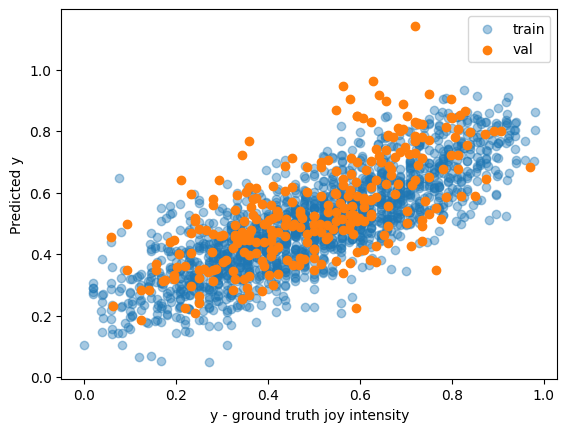

In [31]:
# Use only the regularized model for the results below.
# Create a scatter plot of the actual vs. predicted values of `y` using this function.
def plot(y_train, y_hat_train, y_val, y_hat_val):
    fig, ax = plt.subplots(1)
    ax.scatter(y_train, y_hat_train, alpha=0.4, label='train')
    ax.scatter(y_val, y_hat_val, label='val')
    ax.set_xlabel('y - ground truth joy intensity')
    ax.set_ylabel('Predicted y')
    ax.legend()


# show y_hat versus y on train and val data
with torch.no_grad():  
    y_hat_train = model(X_train)
    y_hat_val = model(X_val)

plot(y_train, y_hat_train, y_val, y_hat_val)

In [38]:
happy = "Kyle made it into UCLA"
sad = "Kyle got rejected from UCLA"

embedding_model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
text_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# Embed the sentences using the embedding model
happy_embedding = embed_sentence(embedding_model, text_tokenizer, happy)
sad_embedding = embed_sentence(embedding_model, text_tokenizer, sad)

# Use trained linear model to predict happiness levels
with torch.no_grad():
    y_hat_happy = model(happy_embedding).item()
    y_hat_sad = model(sad_embedding).item()

print('Happy score: {:0.2f} - {}'.format(y_hat_happy, happy))
print('Happy score: {:0.2f} - {}'.format(y_hat_sad, sad))

Happy score: 0.30 - Kyle made it into UCLA
Happy score: -0.19 - Kyle got rejected from UCLA
